# Assignment 3: Iran War Risk and Global Financial Markets

This project estimates the sensitivity of global financial variables to Iran War Risk from **February 28, 2026 through September 18, 2026**.

The analysis combines:

1. NLP-based identification of high-war-news dates
2. Identification through heteroskedasticity
3. Direct NLP regressions
4. A three-regime bad-news, good-news, and low-news extension
5. Credit excess-return proxies
6. An evaluation of alternative identification methods
7. Validation considerations for novel conflict language

## Research Question

> How sensitive are global financial variables to changes in Iran War Risk during 2026?

Iran War Risk is not directly observable. News coverage provides information about military escalation, nuclear developments, sanctions, diplomatic negotiations, ceasefires, and threats to regional energy infrastructure.

The primary analysis replicates the framework in *The Effects of War Risk on U.S. Financial Markets*. NLP identifies dates with unusually intense Iran-related information, and changes in financial-market variances and covariances across high- and low-news regimes are used for identification.

## Analysis Structure

The analysis proceeds as follows:

1. Collect and clean Iran-related news.
2. Measure relevance, escalation, de-escalation, and intensity using sentence embeddings.
3. Construct a daily Iran War Risk Index.
4. Identify high-news dates and matched low-news dates.
5. Test whether the variance of the reference variable rises in the high-news regime.
6. Estimate market sensitivities through heteroskedasticity.
7. Normalize the latent factor to a 10-basis-point increase in the five-year Treasury yield.
8. Estimate direct NLP regressions using all overlapping dates.
9. Separate bad-war-news, good-war-news, and low-news regimes.
10. Compare the 2026 Iran setting with the 2003 Iraq setting.
11. Evaluate alternative identification methods and NLP limitations.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

ROOT = Path.cwd()

if not (ROOT / "data").exists():
    ROOT = ROOT.parent

news = pd.read_csv(
    ROOT / "data/processed/iran_news_scored.csv"
)

daily_risk = pd.read_csv(
    ROOT / "data/processed/daily_iran_war_risk.csv",
    parse_dates=["market_date"],
)

estimation_sample = pd.read_csv(
    ROOT / "data/processed/estimation_sample.csv",
    parse_dates=["date"],
)

market_changes = pd.read_csv(
    ROOT / "data/processed/market_changes.csv",
    parse_dates=["date"],
)

table_1 = pd.read_csv(
    ROOT / "outputs/tables/table1_high_and_low_news_regimes.csv"
)

table_2 = pd.read_csv(
    ROOT / "outputs/tables/table2_estimated_market_effects.csv"
)

table_3 = pd.read_csv(
    ROOT / "outputs/tables/table3_variance_explained.csv"
)

direct_nlp = pd.read_csv(
    ROOT / "outputs/tables/direct_nlp_regressions.csv"
)

variance_diagnostics = pd.read_csv(
    ROOT / "outputs/tables/variance_regime_diagnostics.csv"
)

appendix_daily = pd.read_csv(
    ROOT / "outputs/tables/appendix_all_daily_war_risk.csv"
)

three_regime_summary = pd.read_csv(
    ROOT / "outputs/tables/three_regime_market_summary.csv"
)

three_regime_regressions = pd.read_csv(
    ROOT / "outputs/tables/three_regime_regressions.csv"
)

validation_sample = pd.read_csv(
    ROOT / "outputs/tables/nlp_validation_sample.csv"
)

ai_evaluation_path = (
    ROOT / "outputs/tables/ai_methodology_evaluation.md"
)

print("All final datasets and tables loaded successfully.")

All final datasets and tables loaded successfully.


## Data Coverage

The raw article collection begins before the final estimation period so the original corpus is preserved. The daily risk index, thresholds, matching procedure, and final market analysis are restricted to February 28, 2026 onward.

Because February 28, 2026 was a Saturday, the first applicable financial-market date is March 2, 2026.

In [2]:
coverage = pd.DataFrame(
    {
        "Dataset": [
            "Scored news articles in raw corpus",
            "Daily risk-index dates in final period",
            "Market dates in final period",
            "Matched high-news observations",
            "Matched low-news observations",
            "Variables in variance diagnostics",
            "Three-regime market dates",
            "NLP validation sample",
        ],
        "Observations": [
            len(news),
            len(daily_risk),
            len(market_changes),
            estimation_sample["regime"].eq("high").sum(),
            estimation_sample["regime"].eq("low").sum(),
            len(variance_diagnostics),
            three_regime_summary[
                three_regime_summary["variable"]
                == "r_vix"
            ]["observations"].sum(),
            len(validation_sample),
        ],
    }
)

coverage

,Dataset,Observations
0,Scored news articles in raw corpus,8472
1,Daily risk-index dates in final period,146
2,Market dates in final period,142
3,Matched high-news observations,15
4,Matched low-news observations,15
5,Variables in variance diagnostics,13
6,Three-regime market dates,142
7,NLP validation sample,50


The final daily risk dataset contains **146 dates**. The merged market and news dataset contains **142 dates**. The heteroskedasticity sample contains **15 high-news dates and 15 matched low-news dates**.

Several market-return series have 138 usable observations because of non-trading days and missing price changes, while the VIX has 142 usable observations.

## News Collection

Iran-related news was collected across three broad categories:

- Military conflict
- Nuclear developments
- Diplomatic negotiations

The corpus contains articles from a broad range of major news outlets. Google News RSS may cap the number of results returned for an individual search. Article counts should therefore be interpreted as the volume observed in the collected sample rather than a complete census of all published news.

The primary daily index gives more weight to semantic event intensity than to raw article counts, reducing—but not eliminating—the effect of capped search results.

## NLP Methodology

The sentence-transformer model `all-MiniLM-L6-v2` converts each headline and RSS description into a semantic embedding.

Each article is compared with seed statements representing:

- Iran-war relevance
- Military escalation
- Diplomatic de-escalation

For article \(i\):

\[
EventStrength_i
=
\max(
Escalation_i,
Deescalation_i
)
\]

\[
WarNewsIntensity_i
=
Relevance_i
\times
EventStrength_i
\]

The maximum of escalation and de-escalation similarity is used because both major escalation and major de-escalation news can produce substantial revisions in perceived war risk.

In [3]:
score_columns = [
    "relevance_score",
    "escalation_score",
    "deescalation_score",
    "war_news_intensity",
    "war_risk_direction",
]

news[score_columns].describe().round(4)

,relevance_score,escalation_score,deescalation_score,war_news_intensity,war_risk_direction
count,"8,472.0000","8,472.0000","8,472.0000","8,472.0000","8,472.0000"
mean,0.4954,0.4385,0.4026,0.2313,0.0183
std,0.0834,0.0839,0.0871,0.0724,0.0403
min,0.0083,0.0185,-0.0123,0.0009,-0.1566
25%,0.4477,0.3859,0.3481,0.1826,-0.0075
50%,0.4999,0.4402,0.4017,0.2301,0.0190
75%,0.5518,0.4947,0.4602,0.2795,0.0449
max,0.7665,0.7597,0.7056,0.5367,0.1697


In [4]:
signal_counts = (
    news["dominant_signal"]
    .value_counts()
    .rename_axis("Dominant Signal")
    .reset_index(name="Articles")
)

signal_counts

,Dominant Signal,Articles
0,escalation,5794
1,deescalation,2678


## Daily Iran War Risk Index

Articles published after 4:00 p.m. Eastern Time are assigned to the following business day. Weekend news is assigned to the next business day.

The daily index is:

\[
RiskIndex_t
=
0.80 Z(Top10Intensity_t)
+
0.20 Z(UncertaintyRate_t)
\]

Using the mean intensity of the ten strongest articles reduces dependence on total article counts. The top 10% of daily index values are classified as high-news dates. Dates below the median are eligible to serve as matched low-news observations.

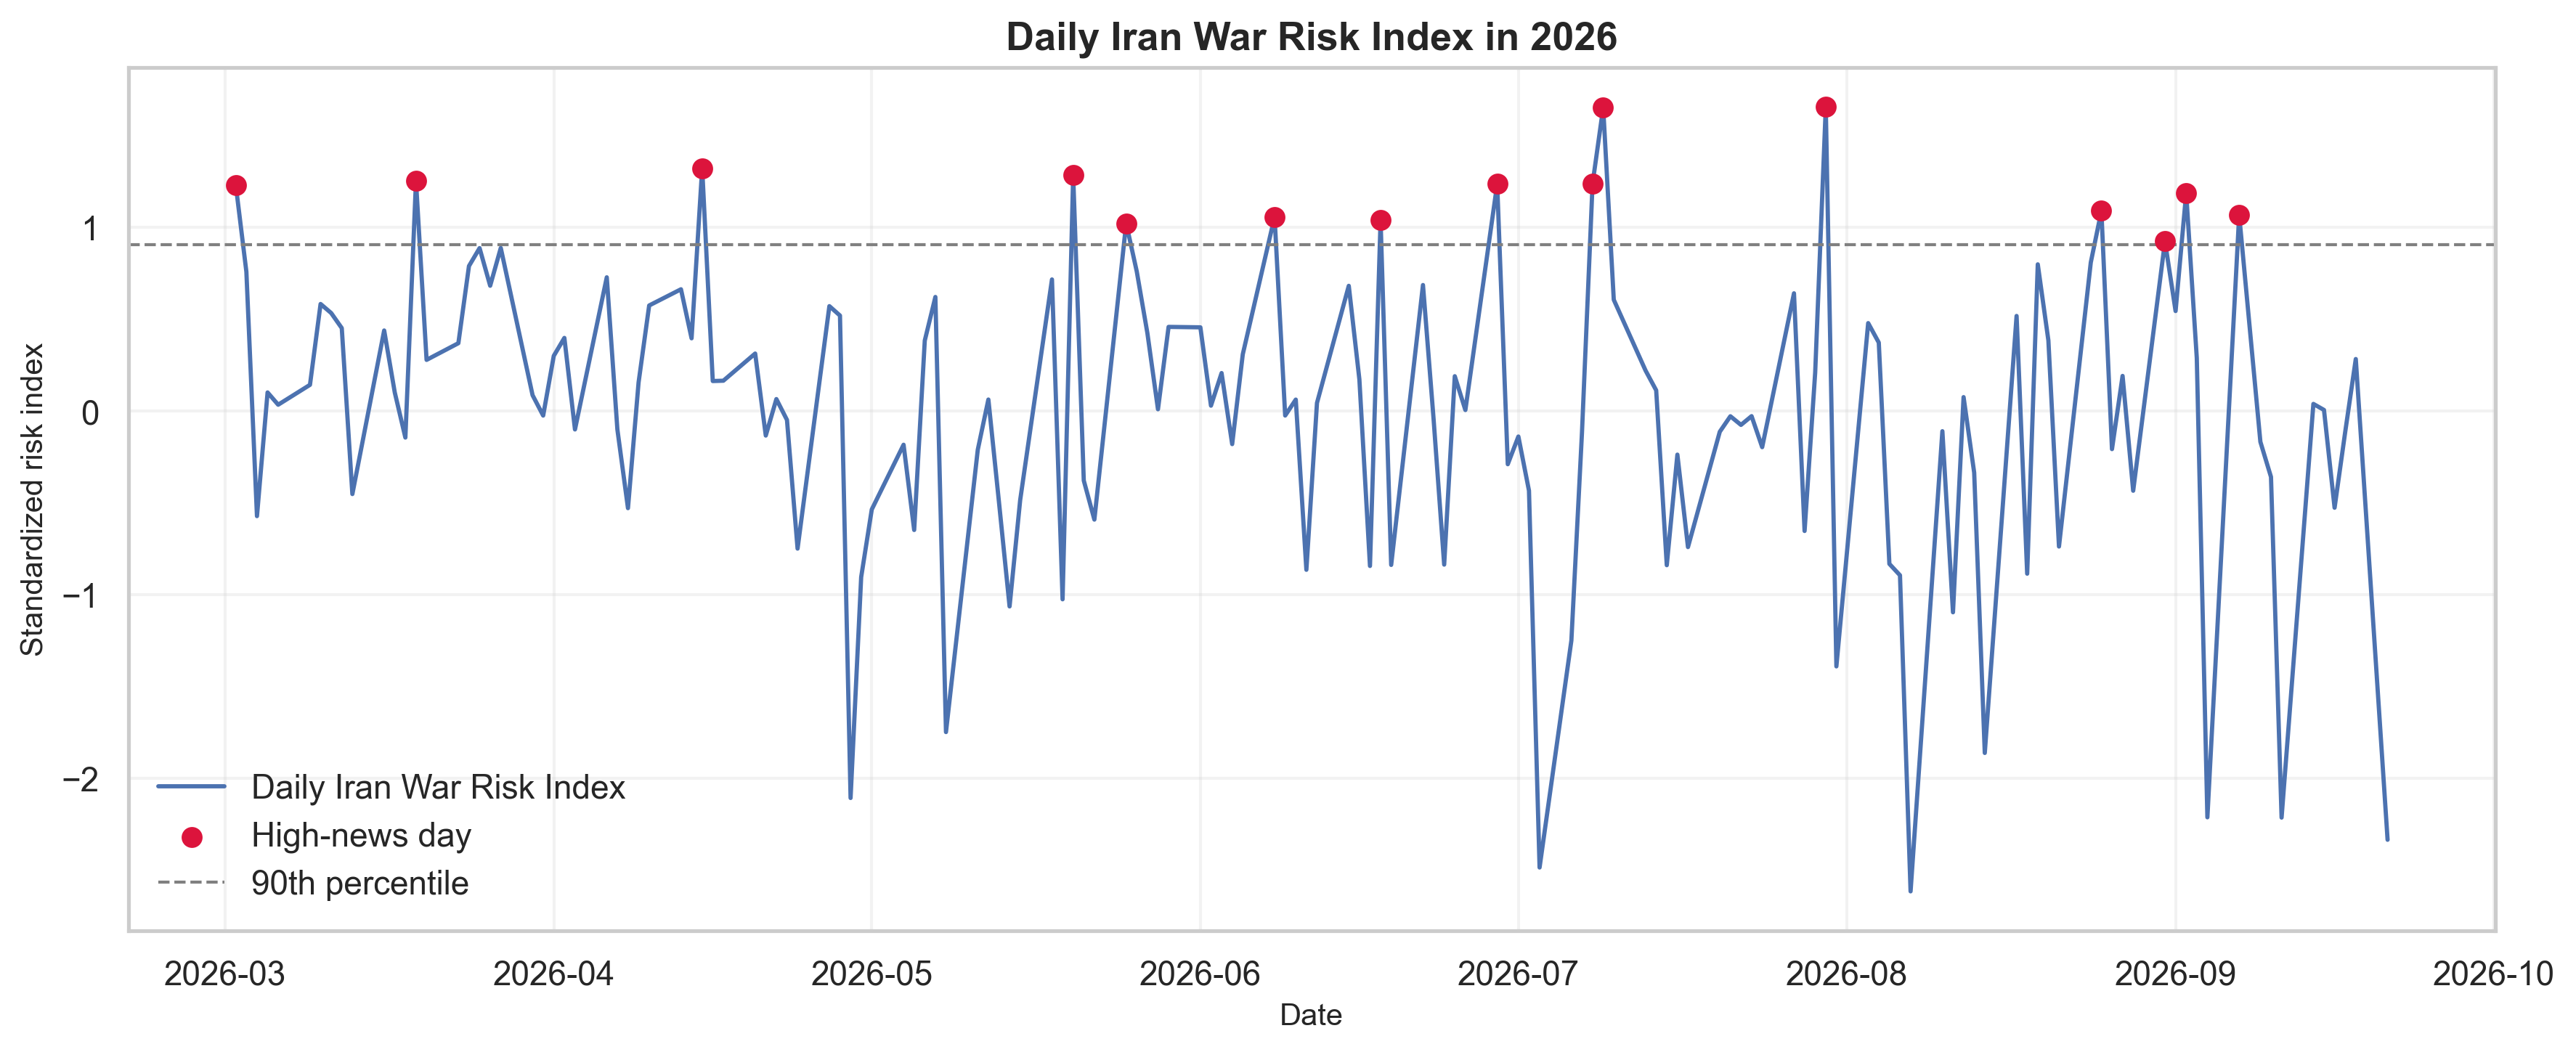

In [5]:
display(
    Image(
        filename=str(
            ROOT
            / "outputs/figures/daily_war_risk_index.png"
        )
    )
)

## Table 1: High- and Low-News Regimes

Table 1 contains the 30 dates used in the heteroskedasticity analysis:

- 15 high-news dates
- 15 uniquely matched low-news dates

The matching criterion minimizes distance in trading days, with lower risk-index values used as a tie-breaker. The median matching distance is one trading day and the maximum is four trading days.

In [6]:
table_1[
    [
        "Date",
        "Regime",
        "NLP Risk Score",
        "News Direction",
        "Article Count",
        "Primary Event",
        "Primary Source",
    ]
]

,Date,Regime,NLP Risk Score,News Direction,Article Count,Primary Event,Primary Source
0,2026-03-02,High variance,1.2306,Escalation,113,"Trump’s war on Iran: grave dangers and, at best, limited benefits",Bulletin of the Atomic Scientists
1,2026-03-19,High variance,1.2537,Escalation,47,How striking Iran’s nuclear power plant may impact the entire region,CNN
2,2026-04-15,High variance,1.3226,Escalation,42,"Pakistani delegation in Tehran aims to ease tensions, arrange U.S.-Iran talks",spectrumlocalnews.com
3,2026-05-20,High variance,1.2836,Escalation,44,Iran threatens to extend conflict ‘beyond the region’ if U.S. and Israel resume attacks,CNBC
4,2026-05-25,High variance,1.0227,Mixed or unclear,90,Iran Talks Bog Down Over Nuclear Program and Sanctions Relief,WSJ
5,2026-06-08,High variance,1.0573,Escalation,71,What Iran and Israel’s escalation means for efforts to end regional conflict,PBS
6,2026-06-18,High variance,1.0397,De-escalation,68,What's in the deal between the US and Iran?,BBC
7,2026-06-29,High variance,1.2362,Escalation,72,Iran Risks Peace Talks With U.S. to Maintain Leverage Over Strait,The New York Times
8,2026-07-08,High variance,1.2387,Escalation,86,Why are the US and Iran fighting again? The feud that keeps threatening peace talks,KCRA
9,2026-07-09,High variance,1.6520,Escalation,68,Renewed US-Iran hostilities highlight Tehran's deep mistrust of negotiations,lemonde.fr


In [7]:
appendix_summary = pd.DataFrame(
    {
        "Appendix Measure": [
            "Daily rows",
            "First date",
            "Last date",
            "High-variance dates",
            "Matched low-variance dates",
            "Other dates",
        ],
        "Value": [
            len(appendix_daily),
            appendix_daily["Date"].min(),
            appendix_daily["Date"].max(),
            appendix_daily["Regime"]
            .eq("High variance")
            .sum(),
            appendix_daily["Regime"]
            .eq("Matched low variance")
            .sum(),
            appendix_daily["Regime"]
            .eq("Other")
            .sum(),
        ],
    }
)

appendix_summary

,Appendix Measure,Value
0,Daily rows,146
1,First date,2026-03-02
2,Last date,2026-09-21
3,High-variance dates,15
4,Matched low-variance dates,15
5,Other dates,116


## Financial Variables

The analysis includes:

- Five-year and ten-year U.S. Treasury yields
- S&P 500
- Global equities
- Investment-grade corporate bonds
- High-yield corporate bonds
- Inflation-linked Treasury bonds
- Brent crude oil
- Gold
- U.S. Dollar Index
- VIX
- Investment-grade credit excess-return proxy
- High-yield credit excess-return proxy

Yield changes are measured in percentage points. Prices and indices are measured using percentage log returns.

The credit variables are not actual option-adjusted spreads. They are calculated as corporate-bond ETF returns minus inflation-linked Treasury ETF returns:

\[
IGProxy_t = r_{LQD,t} - r_{TIP,t}
\]

\[
HYProxy_t = r_{HYG,t} - r_{TIP,t}
\]

A negative proxy value indicates corporate credit underperformance relative to Treasury inflation-protected bonds and is directionally consistent with weaker credit conditions or wider spreads.

## Identification Through Heteroskedasticity

Let:

\[
\Delta X_t = D z_t + \mu_t
\]

where \(z_t\) is the unobservable Iran War Risk factor, \(D\) contains financial-market sensitivities, and \(\mu_t\) represents other financial shocks.

Define:

\[
\Omega_H = Var(\Delta X_t \mid H)
\]

\[
\Omega_L = Var(\Delta X_t \mid L)
\]

The covariance difference is:

\[
\Delta\Omega = \Omega_H - \Omega_L
\]

If the main difference between regimes is a change in the variance of Iran War Risk, the change in covariance identifies the relative factor loadings.

Using the five-year Treasury yield as the reference variable:

\[
\widehat d_j =
\frac{
Cov_H(\Delta x_1,\Delta x_j)
-
Cov_L(\Delta x_1,\Delta x_j)
}{
Var_H(\Delta x_1)
-
Var_L(\Delta x_1)
}
\]

Heteroskedasticity identifies the factor only up to scale and sign. The factor is therefore normalized to a **10-basis-point increase in the five-year Treasury yield**, consistent with the Iran-specific inflation, energy-price, debt-risk, and weaker-flight-to-quality channels described in the assignment guidance.

Directional NLP regressions are used as an additional interpretation check rather than treating the sign normalization as independently identified.

## Variance-Regime Validation

The reference-variable variance must be higher in the high-news regime for the identification strategy to be informative.

In [8]:
variance_display = variance_diagnostics[
    [
        "variable",
        "high_observations",
        "low_observations",
        "variance_low",
        "variance_high",
        "variance_difference",
        "variance_ratio",
        "levene_pvalue",
    ]
].copy()

variance_display.round(4)

,variable,high_observations,low_observations,variance_low,variance_high,variance_difference,variance_ratio,levene_pvalue
0,d_five_year_yield,13,15,0.0011,0.0027,0.0015,2.3509,0.2563
1,d_ten_year_yield,13,15,0.0008,0.0021,0.0013,2.5521,0.2057
2,r_sp500,13,15,0.4612,0.3689,-0.0923,0.7998,0.8416
3,r_global_equity,13,15,0.5977,0.5298,-0.0679,0.8863,0.6949
4,r_investment_grade_bonds,13,15,0.0874,0.0981,0.0108,1.1232,0.9719
5,r_high_yield_bonds,13,15,0.0446,0.0408,-0.0039,0.9137,0.9865
6,r_inflation_linked_bonds,13,15,0.0481,0.0355,-0.0126,0.7377,0.7881
7,r_brent_oil,13,15,3.2318,10.7053,7.4735,3.3125,0.1867
8,r_gold,13,15,1.3396,4.1604,2.8208,3.1058,0.2916
9,r_dollar_index,13,15,0.0688,0.2031,0.1342,2.9507,0.5175


The five-year Treasury yield variance ratio is approximately **2.35**, satisfying the required variance-direction condition. Seven of the thirteen variables have higher variance on high-news dates.

The individual Levene tests are not statistically significant, which is unsurprising with only 15 matched observations per regime. The analysis should therefore be interpreted cautiously because the sample provides limited power for detecting variance differences.

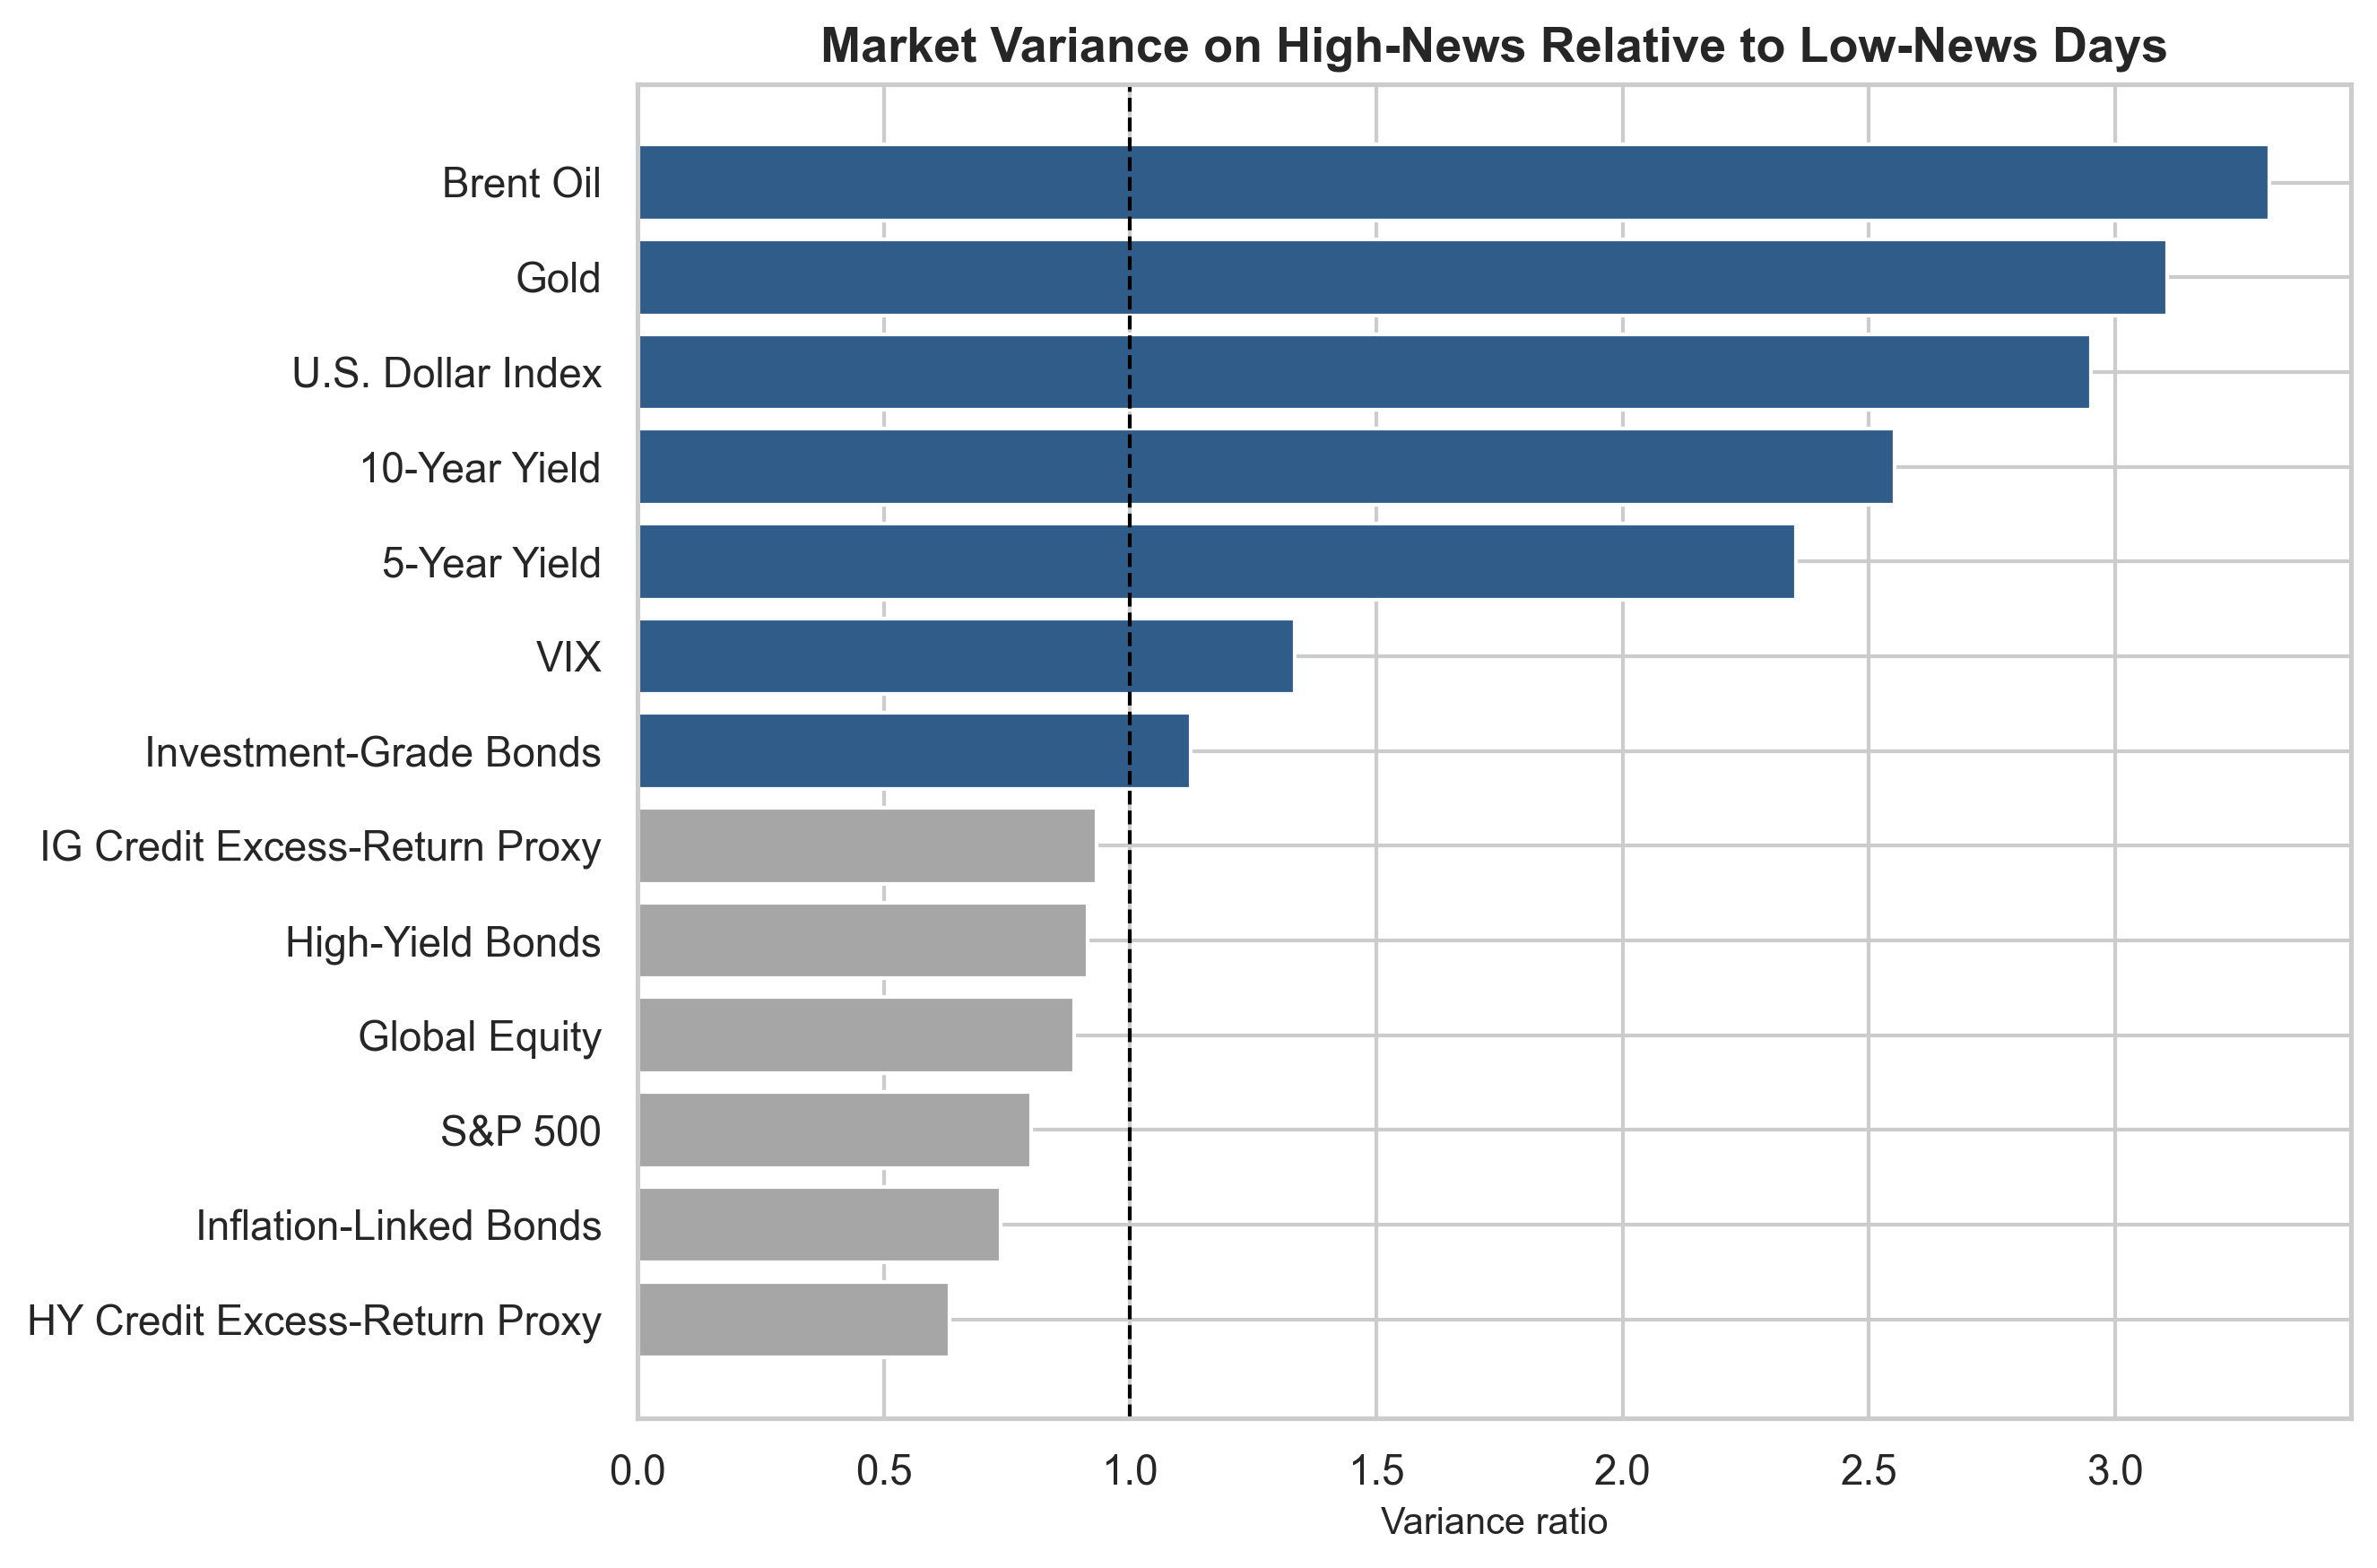

In [9]:
display(
    Image(
        filename=str(
            ROOT
            / "outputs/figures/variance_ratios.png"
        )
    )
)

## Table 2: Estimated Impact of an Increase in Iran War Risk

The estimated effects are normalized to a 10-basis-point increase in the five-year Treasury yield. Bootstrap confidence intervals are reported for the combined estimator.

In [10]:
table_2

,Financial Variable,Units,Estimator 1,Estimator 2,Combined IV,95% CI Low,95% CI High,Significant at 5%
0,10-Year Treasury Yield,Basis-point change,9.1620,9.0960,9.0460,3.6300,12.0750,True
1,S&P 500,Percent change,-0.3120,1.9200,-0.4720,-2.5410,1.8900,False
2,Global Equity,Percent change,-0.6150,0.7160,-0.7510,-3.9520,2.0310,False
3,Investment-Grade Bonds,Percent change,-0.3420,-0.2040,-0.3810,-1.4420,0.3120,False
4,High-Yield Bonds,Percent change,-0.1550,0.1610,-0.2200,-1.0950,0.1300,False
5,Inflation-Linked Bonds,Percent change,-0.1360,0.6030,-0.3210,-1.2060,-0.0620,True
6,Brent Oil,Percent change,8.1200,5.9690,5.3240,-1.2210,7.3560,False
7,Gold,Percent change,-1.2450,-14.6930,-1.7540,-12.2680,6.0150,False
8,U.S. Dollar Index,Percent change,-0.0960,-9.0740,-0.5530,-2.8330,1.6170,False
9,VIX,Percent change,5.8940,14.2370,6.3680,-16.7410,25.3560,False


## Interpretation of Table 2

The central heteroskedasticity results are:

- The ten-year Treasury yield increases by approximately **9.05 basis points**, with a 95% confidence interval of approximately 3.63 to 12.08 basis points.
- The S&P 500 response is approximately **-0.47%**, but is not statistically significant.
- Global equities decline by approximately **-0.75%**, but the estimate is imprecise.
- Investment-grade and high-yield bond returns are negative but insignificant.
- Inflation-linked bonds decline by approximately **-0.32%**, with a confidence interval below zero.
- Brent oil increases by approximately **5.32%**, but the confidence interval includes zero.
- VIX increases by approximately **6.37%**, but with a wide confidence interval.
- The investment-grade credit excess-return proxy is negative, which is directionally consistent with weaker credit conditions, but it is not statistically significant.
- The high-yield credit proxy is close to zero and statistically insignificant.

These estimates provide economically meaningful signs for several variables, but the small matched sample creates substantial uncertainty.

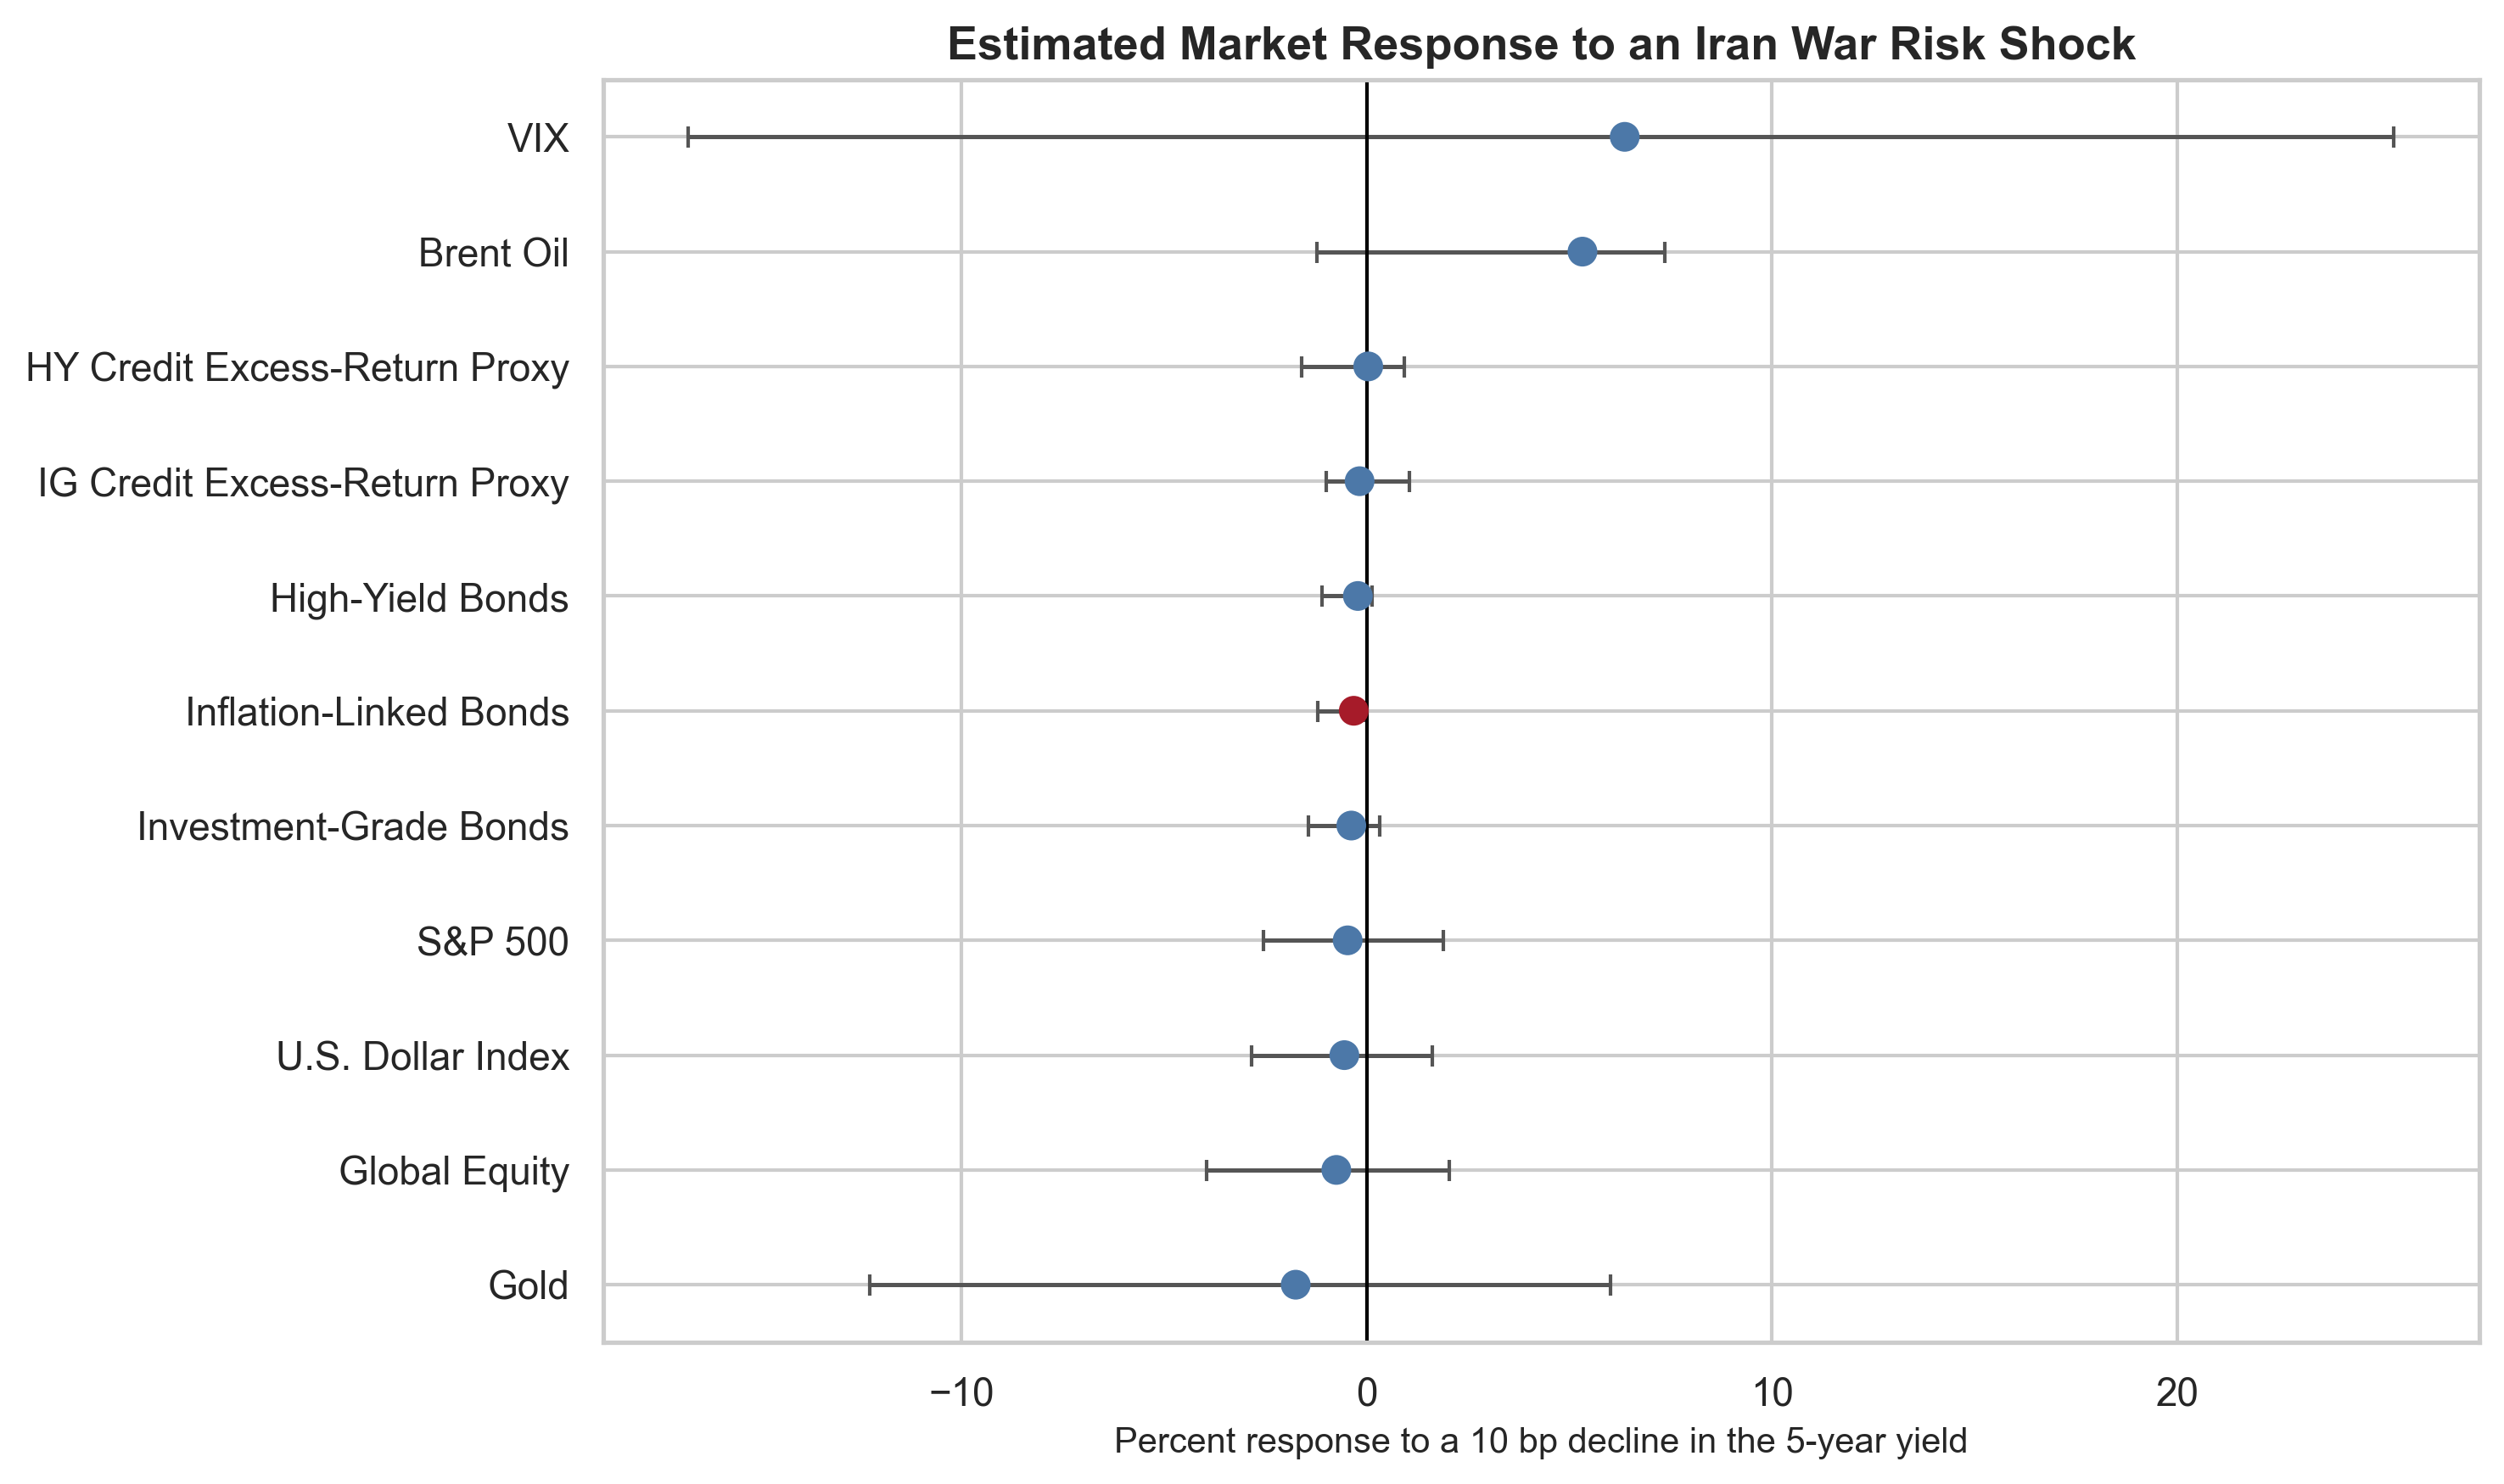

In [11]:
display(
    Image(
        filename=str(
            ROOT
            / "outputs/figures/estimated_market_effects.png"
        )
    )
)

## Table 3: Variance Explained by Iran War Risk

For financial variable \(j\):

\[
\widehat{\Delta Var_j}
=
\widehat d_j^2
\left[
Var_H(\Delta x_1)
-
Var_L(\Delta x_1)
\right]
\]

The share of high-news-day variance explained is:

\[
Share_{j,H}
=
\frac{
\widehat{\Delta Var_j}
}{
Var_H(\Delta x_j)
}
\]

In [12]:
table_3

,Financial Variable,Variance on Low Days,Variance on High Days,Predicted Change in Variance,Explained on High Days (%),Explained in Full Sample (%)
0,5-Year Treasury Yield,0.0011,0.0027,NaN,NaN,NaN
1,10-Year Treasury Yield,0.0008,0.0021,0.0013,59.7200,6.4300
2,S&P 500,0.4612,0.3689,0.0343,9.2900,0.4400
3,Global Equity,0.5977,0.5298,0.0870,16.4200,0.8400
4,Investment-Grade Bonds,0.0874,0.0981,0.0224,22.8300,1.4400
5,High-Yield Bonds,0.0447,0.0408,0.0074,18.2300,0.9000
6,Inflation-Linked Bonds,0.0481,0.0355,0.0159,44.7200,2.7800
7,Brent Oil,3.2318,10.7053,4.3711,40.8300,2.1900
8,Gold,1.3396,4.1604,0.4744,11.4000,1.5900
9,U.S. Dollar Index,0.0688,0.2031,0.0472,23.2400,3.9400


The estimated variance contributions are largest for the ten-year Treasury yield, inflation-linked bonds, and Brent oil. A large estimated variance contribution does not imply that the directional coefficient is precisely estimated. Brent oil, for example, has a large variance contribution but a wide directional confidence interval.

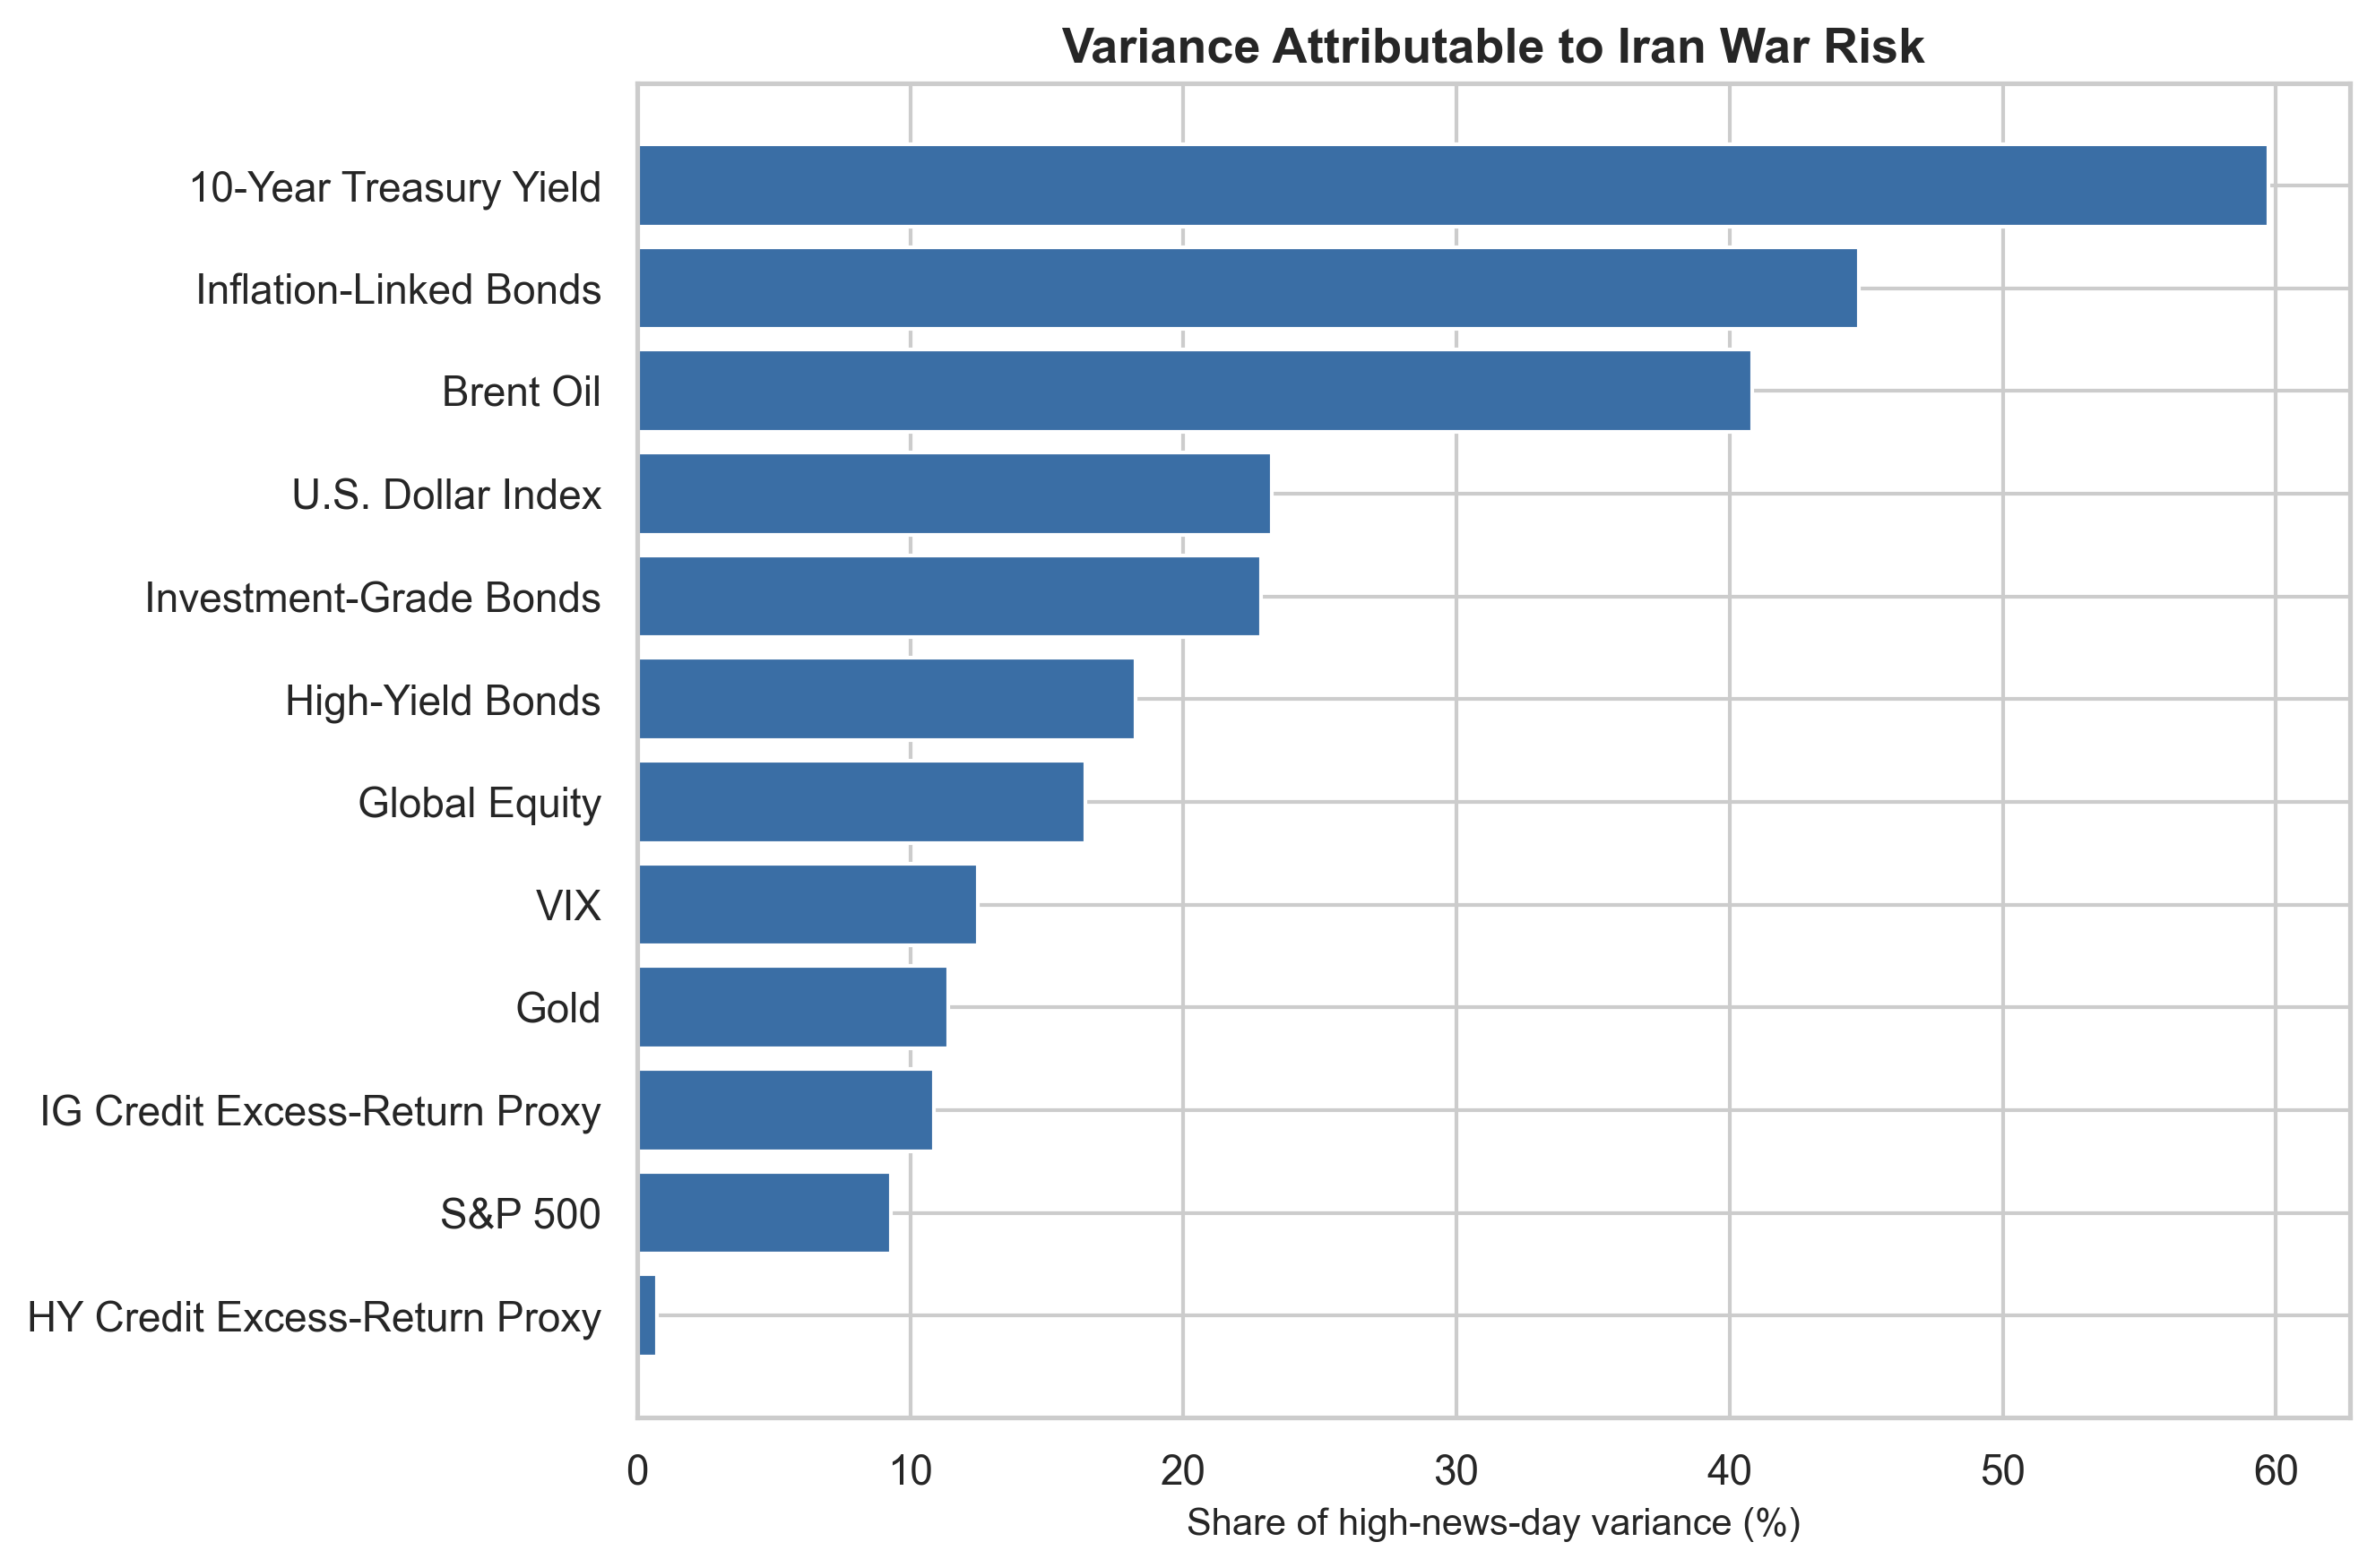

In [13]:
display(
    Image(
        filename=str(
            ROOT
            / "outputs/figures/variance_explained.png"
        )
    )
)

## Alternative Method: Direct NLP Regressions

The direct directional regression is:

\[
\Delta x_{j,t}
=
\alpha_j
+
\beta_j SignedRisk_t
+
\varepsilon_{j,t}
\]

The intensity regression is:

\[
|\Delta x_{j,t}|
=
\alpha_j
+
\gamma_j RiskIntensity_t
+
\varepsilon_{j,t}
\]

The NLP variables are standardized, and HC3 heteroskedasticity-consistent standard errors are used.

### Directional NLP Results

In [14]:
direction_columns = [
    "label",
    "direction_coefficient",
    "direction_standard_error",
    "direction_p_value",
    "direction_r_squared",
    "direction_significant",
]

if "observations" in direct_nlp.columns:
    direction_columns.insert(1, "observations")

direction_table = direct_nlp[
    direction_columns
].copy()

direction_table.round(4)

,label,observations,direction_coefficient,direction_standard_error,direction_p_value,direction_r_squared,direction_significant
0,5-Year Treasury Yield,138,0.0046,0.0037,0.2128,0.0092,False
1,10-Year Treasury Yield,138,0.0069,0.0033,0.0340,0.0260,True
2,S&P 500,138,-0.1131,0.0790,0.1522,0.0175,False
3,Global Equity,138,-0.1086,0.0887,0.2209,0.0121,False
4,Investment-Grade Bonds,138,-0.0388,0.0326,0.2342,0.0104,False
5,High-Yield Bonds,138,-0.0042,0.0253,0.8686,0.0002,False
6,Inflation-Linked Bonds,138,-0.0191,0.0218,0.3820,0.0068,False
7,Brent Oil,138,0.8428,0.3385,0.0128,0.0380,True
8,Gold,138,0.0065,0.1588,0.9671,0.0000,False
9,U.S. Dollar Index,138,-0.0283,0.0307,0.3560,0.0071,False


A one-standard-deviation increase in escalation language is associated with:

- A positive but insignificant change in the five-year Treasury yield.
- A statistically significant increase in the ten-year Treasury yield.
- A statistically significant increase in Brent oil.
- Negative S&P 500 and global-equity coefficients, although neither is statistically significant.
- A negative investment-grade credit-proxy coefficient, although it is statistically insignificant.

These results support the assignment's expectation that Iran escalation may increase longer-term yields and oil prices while placing downward pressure on risk assets.

### NLP Intensity and Absolute Market Movement

In [15]:
intensity_columns = [
    "label",
    "intensity_coefficient",
    "intensity_standard_error",
    "intensity_p_value",
    "intensity_r_squared",
    "intensity_significant",
]

if "observations" in direct_nlp.columns:
    intensity_columns.insert(1, "observations")

intensity_table = direct_nlp[
    intensity_columns
].copy()

intensity_table.round(4)

,label,observations,intensity_coefficient,intensity_standard_error,intensity_p_value,intensity_r_squared,intensity_significant
0,5-Year Treasury Yield,138,-0.0013,0.0024,0.5777,0.0022,False
1,10-Year Treasury Yield,138,0.0001,0.0022,0.9475,0.0000,False
2,S&P 500,138,0.0398,0.0384,0.2999,0.0052,False
3,Global Equity,138,0.0457,0.0475,0.3360,0.0050,False
4,Investment-Grade Bonds,138,0.0205,0.0192,0.2847,0.0078,False
5,High-Yield Bonds,138,0.0207,0.0130,0.1098,0.0132,False
6,Inflation-Linked Bonds,138,-0.0200,0.0121,0.0989,0.0180,False
7,Brent Oil,138,0.4709,0.2026,0.0201,0.0272,True
8,Gold,138,0.1840,0.1023,0.0720,0.0286,False
9,U.S. Dollar Index,138,0.0174,0.0201,0.3864,0.0070,False


Higher news intensity is significantly associated with a larger absolute Brent oil movement. The gold intensity coefficient is positive and marginally significant at approximately the 10% level, but not at the 5% level.

The low \(R^2\) values indicate that Iran-news measures explain only a small share of daily market variation. This is expected because daily prices also respond to monetary policy, macroeconomic releases, earnings, and other geopolitical events.

## Three-Regime Extension

The direction-neutral high/low split remains the primary heteroskedasticity design. A separate extension classifies dates into:

1. Bad war news
2. Good war news
3. No or low war news

A date must be above the 75th percentile of the daily risk index to enter a directional high-news regime. Among those dates, a nonnegative weighted direction is classified as bad war news and a negative direction as good war news.

In [16]:
regime_counts = (
    three_regime_summary[
        three_regime_summary["variable"] == "r_vix"
    ][["regime", "observations"]]
    .reset_index(drop=True)
)

regime_counts

,regime,observations
0,Bad war news,30
1,Good war news,6
2,No or low war news,106


In [17]:
selected_variables = [
    "d_five_year_yield",
    "d_ten_year_yield",
    "r_sp500",
    "r_global_equity",
    "r_brent_oil",
    "r_gold",
    "r_vix",
    "r_ig_credit_proxy",
    "r_hy_credit_proxy",
]

three_regime_summary[
    three_regime_summary["variable"].isin(
        selected_variables
    )
][
    [
        "label",
        "regime",
        "observations",
        "mean",
        "median",
        "variance",
        "standard_deviation",
    ]
].round(4)

,label,regime,observations,mean,median,variance,standard_deviation
0,5-Year Treasury Yield,Bad war news,28,0.0135,0.0180,0.0025,0.0504
1,5-Year Treasury Yield,Good war news,5,0.0174,0.0240,0.0008,0.0288
2,5-Year Treasury Yield,No or low war news,105,0.0088,0.0060,0.0023,0.0484
3,10-Year Treasury Yield,Bad war news,28,0.0099,0.0220,0.0020,0.0450
4,10-Year Treasury Yield,Good war news,5,0.0152,0.0240,0.0008,0.0283
5,10-Year Treasury Yield,No or low war news,105,0.0069,0.0080,0.0018,0.0430
6,S&P 500,Bad war news,28,0.0884,0.0280,0.6472,0.8045
7,S&P 500,Good war news,5,0.3458,0.1232,0.3513,0.5927
8,S&P 500,No or low war news,105,0.0610,0.0165,0.7744,0.8800
9,Global Equity,Bad war news,28,0.0534,0.1879,0.9034,0.9505


In [18]:
three_regime_regressions[
    three_regime_regressions["variable"].isin(
        selected_variables
    )
][
    [
        "label",
        "term",
        "coefficient",
        "standard_error",
        "p_value",
        "confidence_low",
        "confidence_high",
        "r_squared",
        "observations",
    ]
].round(4)

,label,term,coefficient,standard_error,p_value,confidence_low,confidence_high,r_squared,observations
0,5-Year Treasury Yield,bad_news_dummy,0.0047,0.0110,0.6713,-0.0168,0.0261,0.0023,138
1,5-Year Treasury Yield,good_news_dummy,0.0086,0.0168,0.6101,-0.0243,0.0414,0.0023,138
2,10-Year Treasury Yield,bad_news_dummy,0.0030,0.0098,0.7571,-0.0161,0.0222,0.0019,138
3,10-Year Treasury Yield,good_news_dummy,0.0083,0.0164,0.6125,-0.0238,0.0404,0.0019,138
4,S&P 500,bad_news_dummy,0.0274,0.1799,0.8791,-0.3253,0.3800,0.0039,138
5,S&P 500,good_news_dummy,0.2848,0.3425,0.4056,-0.3864,0.9560,0.0039,138
6,Global Equity,bad_news_dummy,0.0139,0.2113,0.9476,-0.4003,0.4281,0.0049,138
7,Global Equity,good_news_dummy,0.3742,0.3272,0.2527,-0.2670,1.0155,0.0049,138
14,Brent Oil,bad_news_dummy,-0.1287,0.9632,0.8937,-2.0166,1.7592,0.0008,138
15,Brent Oil,good_news_dummy,0.5456,1.4153,0.6999,-2.2284,3.3196,0.0008,138


The three-regime sample contains approximately 30 bad-news dates, 6 good-news dates, and 106 no- or low-news dates. The directional groups are therefore highly unbalanced.

Most three-regime coefficients are statistically insignificant. The significant good-news coefficient for gold is based on only five usable return observations and should not be generalized.

The extension is useful for illustrating direction, but it is not stronger than the primary high/low heteroskedasticity design because the good-news group is very small.

## Iran 2026 Versus Iraq 2003

| Variable | Iraq War 2003 benchmark | Iran 2026 expectation | Iran 2026 evidence |
|---|---|---|---|
| Treasury yields | Yields fell as investors sought safety | Yields may rise because of inflation, debt concerns, and weaker flight-to-quality demand | Ten-year yield rises significantly in both the normalized heteroskedasticity model and direct NLP regression |
| Oil | Oil increased with perceived supply risk | Oil should increase, although greater U.S. production may reduce the domestic macroeconomic effect | Brent rises in both main approaches; direct NLP coefficient is significant |
| Credit spreads | Spreads widened | Credit conditions should weaken | IG credit proxy is negative but insignificant; HY proxy is inconclusive |
| Equities | Equities fell | Equities should fall | S&P 500 and global-equity estimates are negative in the primary and direct NLP specifications but insignificant |
| Gold | Limited movement in the benchmark | A safe-haven or inflation response is possible | Directional estimates are unstable; intensity is associated with larger gold movements at approximately the 10% level |
| VIX | Risk and uncertainty increased | VIX should increase | Heteroskedasticity estimate is positive but imprecise |

U.S. crude-oil production is substantially higher in 2026 than it was around the Iraq War period—approximately 14 million barrels per day compared with roughly 6 million barrels per day. Greater domestic production may reduce direct U.S. vulnerability to imported supply disruptions.

However, Iran-related conflict can still affect global energy prices through the Strait of Hormuz, regional production, shipping insurance, and the possibility of broader military escalation.

## Novel Language and NLP Validation

Fixed legacy dictionaries may fail to recognize new conflict terminology, indirect references, newly named operations, or evolving diplomatic language.

Sentence embeddings improve on exact keyword matching because semantically similar phrases can receive similar scores even when they do not contain the same words. Nevertheless, embeddings do not eliminate errors arising from:

- Mixed escalation and de-escalation headlines
- Sarcasm or rhetorical language
- Indirect references
- Headlines requiring broader context
- Newly introduced military or diplomatic terminology
- Descriptions that discuss conflict historically rather than as a new event

A stratified 50-article validation sample was created from:

- 20 highest-intensity articles
- 15 articles near the intensity threshold
- 15 randomly selected articles

The manual-label columns are intentionally left separate from the model output. No manual accuracy statistic is reported until those labels are completed.

In [19]:
validation_sample[
    [
        "sample_type",
        "published_utc",
        "title_clean",
        "source",
        "predicted_signal",
        "war_news_intensity",
        "war_risk_direction",
        "manual_label",
        "classification_correct",
        "novel_phrasing",
        "notes",
    ]
].head(15)

,sample_type,published_utc,title_clean,source,predicted_signal,war_news_intensity,war_risk_direction,manual_label,classification_correct,novel_phrasing,notes
0,Highest intensity,2026-05-26 07:00:00+00:00,"US-Iran tensions rise, putting peace talks at risk",The Hill,deescalation,0.5367,-0.0551,NaN,NaN,NaN,NaN
1,Highest intensity,2026-05-18 07:00:00+00:00,The Escalation Trajectory of U.S.-Iran Tensions After the Collapse of the Negotiations,globalsecurityreview.com,escalation,0.5245,0.0277,NaN,NaN,NaN,NaN
2,Highest intensity,2026-04-06 07:00:00+00:00,Iran war on verge of escalation as Trump and Tehran exchange threats,PBS,escalation,0.5056,0.1149,NaN,NaN,NaN,NaN
3,Highest intensity,2026-08-25 07:00:00+00:00,"Iran vows retaliation after U.S. widens sanctions, fueling fears of escalated war",NBC News,escalation,0.5037,0.1362,NaN,NaN,NaN,NaN
4,Highest intensity,2026-05-20 07:00:00+00:00,Iran threatens to extend conflict ‘beyond the region’ if U.S. and Israel resume attacks,CNBC,escalation,0.5023,0.1573,NaN,NaN,NaN,NaN
5,Highest intensity,2026-09-02 07:00:00+00:00,The Iran Conflict,Ipsos,escalation,0.4957,0.0688,NaN,NaN,NaN,NaN
6,Highest intensity,2026-03-03 08:00:00+00:00,Iran Escalates Attacks on Gulf Nations as Conflict Widens,WSJ,escalation,0.4767,0.1213,NaN,NaN,NaN,NaN
7,Highest intensity,2026-07-30 07:00:00+00:00,Tehran tests a more confrontational strategy,Iran International,escalation,0.4714,0.0471,NaN,NaN,NaN,NaN
8,Highest intensity,2026-06-22 07:00:00+00:00,How the Iran Deal Sets the Stage for More Conflict,Foreign Policy,escalation,0.4642,0.0241,NaN,NaN,NaN,NaN
9,Highest intensity,2026-05-20 07:00:00+00:00,Iran threatens war ‘beyond the region’ if U.S. attacks,NBC News,escalation,0.4633,0.1697,NaN,NaN,NaN,NaN


## Evaluation of Alternative Identification Methods

Identification through heteroskedasticity is appropriate as the **primary replication method**, but it is not independently conclusive.

| Method | Main advantage | Main weakness | Role in this project |
|---|---|---|---|
| Identification through heteroskedasticity | Addresses simultaneity without requiring perfect observation of the latent shock | Strong regime-stability assumptions, small-sample instability, and sign normalization | Primary replication |
| Direct NLP regression | Uses nearly all dates and provides directional interpretation | Omitted-variable bias and NLP measurement error | Main robustness test |
| Three-regime analysis | Separates bad and good war news | Very small good-news group | Exploratory extension |
| Traditional event study | Clear interpretation around precisely timed events | Contamination and timing requirements | Useful for selected major events |
| Local projections | Estimates dynamic responses over several horizons | Requires more observations | Future extension |
| Structural VAR | Models joint market dynamics and feedback | Strong ordering restrictions and overparameterization | Less suitable for the short sample |
| External-instrument IV | Potentially strong causal interpretation | A credible instrument and exclusion restriction are difficult to establish | Theoretically attractive but impractical here |
| Narrative identification | Uses expert-reviewed surprise events | Subjective and produces few observations | Useful for validation |

The preferred strategy is therefore:

1. Use heteroskedasticity identification as the primary replication.
2. Use direct NLP regressions as the main robustness analysis.
3. Use the three-regime analysis as a directional extension.
4. Use manual headline review to assess NLP classification quality.
5. Consider a narrow event-study appendix for a few precisely timed events.

Conclusions are strongest when the different approaches produce economically consistent patterns.

In [20]:
if ai_evaluation_path.exists():
    evaluation_text = ai_evaluation_path.read_text(
        encoding="utf-8"
    )
    display(Markdown(evaluation_text))
else:
    print(
        "Separate methodology evaluation file "
        "was not found."
    )

## Evaluation of Identification Through Heteroskedasticity

Identification through heteroskedasticity is an appropriate **primary methodology for replicating the war-risk paper**, but it is not necessarily the best standalone method for establishing causality in this application. Given the short 2026 sample, it should be combined with direct NLP regressions and a three-regime analysis.

### Identification through heteroskedasticity

The method compares changes in market variances and covariances between high-war-news and low-war-news regimes. If war-risk shocks become more volatile on high-news days while the relationships among other market shocks remain stable, the change in covariance can identify financial-market sensitivity to the latent war-risk factor.

Its principal advantage is that the exact magnitude and direction of every news story do not need to be measured. NLP only needs to identify days on which war-related information is unusually important. This is valuable because individual stories may contain mixed escalation and de-escalation signals.

The method also helps address simultaneity. Treasury yields, oil prices, equities, credit markets, and volatility can respond to war risk at the same time, making an ordinary regression difficult to interpret. Heteroskedasticity-based identification uses the change in the covariance structure rather than assuming that one observed market variable is completely exogenous.

However, the method relies on strong assumptions:

1. War-risk shocks must be more volatile on high-news days than on low-news days.
2. The structural relationships between war risk and financial variables must remain stable across regimes.
3. The variances and covariance structures of other shocks should not change systematically between the two regimes.
4. High-news days should not consistently coincide with monetary-policy announcements, inflation releases, employment reports, or unrelated geopolitical events.
5. The NLP classification must separate high- and low-information days sufficiently well.
6. A one-factor representation must be adequate even though war news can affect markets through several channels, including inflation, risk aversion, energy supply, and flight-to-quality demand.

The approach identifies relative factor loadings only up to scale and sign. Therefore, normalizing the factor to a 10-basis-point increase in the five-year Treasury yield is an interpretation choice, not a direction learned purely from the variance shift. Directional NLP evidence should be used to assess whether that normalization is economically reasonable.

The small number of high-news and matched low-news observations also produces wide confidence intervals and potentially unstable estimates. For this reason, the results should be described as conditional evidence of market sensitivity rather than definitive causal estimates.

## Comparison with Alternative Methods

| Method                                    | Main advantage                                                               | Main limitation                                                                            | Suitability for this project                           |
| ----------------------------------------- | ---------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------ | ------------------------------------------------------ |
| Identification through heteroskedasticity | Addresses simultaneity without requiring a perfectly observed war-risk shock | Strong regime-stability assumptions; small-sample instability; sign normalization required | Best primary method for replicating the assigned paper |
| Traditional event study                   | Provides intuitive market responses around clearly defined events            | Requires precise event timing and uncontaminated windows                                   | Useful only for a selected set of major announcements  |
| Direct NLP regression                     | Uses the full daily sample and incorporates escalation direction             | Vulnerable to omitted variables, reverse causality, and measurement error                  | Strongest practical robustness test                    |
| Local projections                         | Estimates responses over several future horizons                             | Requires substantially more observations and careful controls                              | Better as a future extension than a principal method   |
| Structural VAR                            | Models interactions and dynamic feedback among markets                       | Sensitive to variable ordering and other identification restrictions                       | Not ideal for the short 2026 sample                    |
| External-instrument IV                    | Can provide stronger causal identification with a valid instrument           | Finding a relevant instrument that affects markets only through Iran War Risk is difficult | Attractive in theory but impractical here              |
| Narrative identification                  | Uses expert-reviewed events to isolate plausibly exogenous shocks            | Subjective and time-intensive; may produce very few events                                 | Useful as a validation exercise                        |
| Three-regime analysis                     | Separates bad, good, and low war news and makes directional effects visible  | Directional groups are small and NLP classification errors matter                          | Valuable exploratory extension                         |

### 1. Traditional event studies

An event study would estimate market movements within narrow windows around major Iran-related announcements or military events. This provides a clear and easily interpreted comparison of pre-event and post-event prices.

Its weakness is event contamination. Important Iran news may occur on the same day as Federal Reserve announcements, inflation data, earnings releases, or other geopolitical developments. Daily data also provide weak timing precision because both the news and the market response may occur within the same day.

An event study is therefore useful for a small set of major, precisely timed events but should not replace the primary heteroskedasticity analysis.

### 2. Direct NLP regressions

Direct regressions relate daily financial-market changes to observed NLP measures such as escalation direction and news intensity. They use substantially more observations than the matched high/low design and provide directional interpretation.

For example, the regression can directly test whether escalation language is associated with higher Treasury yields, higher oil prices, lower equity returns, and higher volatility.

However, these regressions may suffer from omitted-variable bias. Market conditions may affect the volume and tone of news coverage, and both news language and financial prices may respond to the same underlying event. Consequently, the regressions measure conditional same-day associations unless stronger identification is introduced.

Despite this limitation, direct NLP regressions are the most useful robustness method for the current project because they use the full sample and provide the directional information that heteroskedasticity alone cannot identify.

### 3. Local projections

Local projections could estimate the response of each market variable over several days following a war-risk shock. This would help determine whether the effect is temporary, delayed, or persistent.

The principal problem is sample size. A February-to-September daily sample is short, and estimating multiple horizons would quickly reduce statistical power. Overlapping observations would also require appropriate standard errors.

Local projections would become more useful with a longer sample or higher-frequency data.

### 4. Structural VAR models

A structural vector autoregression could jointly model war risk, Treasury yields, oil, equities, and other variables. It would capture feedback and dynamic interactions.

Its conclusions would depend heavily on the chosen ordering, sign restrictions, or contemporaneous restrictions. With many financial variables and a short sample, the system would also be overparameterized and unstable.

A structural VAR is therefore less suitable than a direct regression or local projection for the current dataset.

### 5. External-instrument IV

An external-instrument approach could identify war-risk shocks using an instrument correlated with Iran-related escalation but unrelated to other determinants of global financial markets.

If a credible instrument existed, this could provide stronger causal identification. In practice, military announcements, sanctions, or geopolitical surprises may directly affect energy markets, inflation expectations, or general risk sentiment. This makes the exclusion restriction difficult to defend.

External-instrument IV is theoretically attractive but not currently practical without a carefully justified instrument.

### 6. Narrative identification

Narrative identification would manually classify major events according to their timing, surprise content, and likely direction. This could distinguish unexpected escalation from events that markets had already anticipated.

Manual review can improve the interpretation of novel conflict language and identify false NLP classifications. However, the classification involves researcher judgment and may leave only a very small number of usable events.

It is most useful as validation for the NLP classifications and for constructing a limited event-study appendix.

### 7. Three-regime analysis

A three-regime design separates:

* Bad war news
* Good war news
* No or low war news

This is more informative than a direction-neutral high/low split when the purpose is to examine whether bad news raises yields and oil prices while lowering equities.

Its main weakness is the small and unbalanced directional sample. In the present analysis, there are considerably fewer good-news dates than bad-news dates. Estimates for the good-news regime are therefore especially imprecise. The results should be interpreted as exploratory rather than causal.

## Recommended Methodological Strategy

Identification through heteroskedasticity should remain the **primary method** because the assignment requests a replication of the original war-risk paper and because the technique does not require the latent war-risk shock to be measured perfectly.

It should not be used alone. The preferred empirical strategy is:

1. **Primary specification:** Direction-neutral high-news versus matched low-news identification through heteroskedasticity.
2. **Primary robustness test:** Direct daily NLP regressions using escalation direction and news intensity.
3. **Directional extension:** Three-regime bad-news, good-news, and no-news analysis.
4. **Validation:** Manual review of a stratified sample of headlines to assess novel language and classification errors.
5. **Optional extension:** A narrow event study of a few major, precisely timed Iran-related events.

Local projections, structural VARs, and external-instrument IV are less suitable for the present short sample. They would require more observations, stronger identifying assumptions, or a credible external instrument.

## Conclusion

Identification through heteroskedasticity is the best **primary replication method**, but not an independently conclusive causal design. Its usefulness comes from exploiting variance changes without requiring perfect measurement of each war-risk shock. Its limitations arise from the small matched sample, possible contamination by other market events, structural-stability assumptions, and sign-normalization ambiguity.

The most defensible conclusion should therefore be based on convergence across methods. Evidence is stronger when heteroskedasticity estimates, direct NLP regressions, and three-regime comparisons produce economically consistent patterns. When the methods disagree, the differences should be reported and interpreted rather than forcing a single conclusion.


## Assumptions

The heteroskedasticity interpretation depends on the following assumptions:

1. Iran War Risk is the principal factor whose variance changes between the selected regimes.
2. Financial-market factor loadings remain stable across regimes.
3. Iran War Risk is sufficiently independent of other structural shocks.
4. The variances of unrelated shocks do not change systematically across regimes.
5. High-news dates are not systematically contaminated by monetary-policy, inflation, employment, or unrelated geopolitical announcements.
6. The factor structure is approximately linear.
7. The NLP index correctly separates relatively high- and low-information dates.

The direct NLP regressions additionally require the signed NLP score to contain meaningful directional information and not merely reflect market reactions already incorporated into news coverage.

## Limitations

The main limitations are:

- The final period covers only February 28 through September 18, 2026.
- The heteroskedasticity design uses only 15 matched pairs.
- Some high-news return series contain only 13 usable observations.
- Google News RSS may cap results.
- NLP is applied to headlines and short descriptions rather than full articles.
- Novel or mixed language may be misclassified.
- The good-news regime contains only six dates.
- The five-year Treasury yield replaces the two-year yield used in the original paper.
- The sign of the latent factor is imposed through normalization.
- LQD and HYG returns are not actual credit spreads.
- The credit excess-return measures are only proxies.
- Macroeconomic and monetary-policy events may overlap with Iran news.
- Individual variance-difference tests have limited power.
- Several confidence intervals are wide.
- Direct NLP regressions have low explanatory power.
- Results depend on the NLP seeds, thresholds, and matching procedure.

The estimates should be interpreted as conditional market sensitivities under the model assumptions, not as unconditional proof that Iran War Risk caused every observed market movement.

## Conclusion

The updated analysis identifies 15 high-news dates and 15 matched low-news dates between February 28 and September 18, 2026. The five-year Treasury yield variance is approximately 2.35 times higher in the high-news regime, supporting the variance-direction condition required for heteroskedasticity-based identification.

Under normalization to a 10-basis-point increase in the five-year Treasury yield, the ten-year yield increases significantly by approximately 9.05 basis points. Equity responses are negative, Brent oil and VIX responses are positive, and investment-grade credit conditions weaken, although these estimates are generally imprecise.

The direct NLP regressions provide important complementary evidence. Escalation language is associated with a significant increase in the ten-year Treasury yield and Brent oil. Equity coefficients are negative but insignificant. Higher news intensity is associated with significantly larger absolute Brent movements.

The three-regime analysis provides directional context but is limited by only six good-news dates. Credit excess-return proxies are directionally informative but statistically insignificant.

Overall, the evidence suggests that Iran War Risk in 2026 is most clearly reflected in longer-term Treasury yields and oil prices. The results differ from the traditional Iraq-era flight-to-quality pattern because Iran risk may operate through inflation, energy supply, sovereign-debt concerns, and weaker demand for Treasuries as safe assets.

Identification through heteroskedasticity remains the appropriate primary replication method, while direct NLP regressions and the three-regime analysis provide necessary robustness and interpretation.

## References

Rigobon, R. (2003). Identification through Heteroskedasticity. *The Review of Economics and Statistics*, 85(4), 777–792.

Rigobon, R., and Sack, B. (2003). The Effects of War Risk on U.S. Financial Markets. *NBER Working Paper No. 9609*.

Caldara, D., and Iacoviello, M. (2022). Measuring Geopolitical Risk. *American Economic Review*, 112(4), 1194–1225.